<a href="https://colab.research.google.com/github/nnott3/KilterTransformer/blob/main/notebooks/gpt_shuffle_me.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!git clone https://github.com/nnott3/KilterTransformer.git
%cd KilterTransformer
!ls

Cloning into 'KilterTransformer'...
remote: Enumerating objects: 360, done.
remote: Counting objects: 100% (187/187), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 360 (delta 108), reused 82 (delta 35), pack-reused 173 (from 1)
Receiving objects: 100% (360/360), 126.93 MiB | 27.30 MiB/s, done.
Resolving deltas: 100% (181/181), done.
Updating files: 100% (59/59), done.
/content/KilterTransformer
bert_improved.ipynb  gitignore		notebooks	   saved_models
bert.ipynb	     gpt_shuffle.ipynb	project_structure  src
data		     gpt_wandb.ipynb	pyproject.toml	   utils_old
EDA.ipynb	     main.ipynb		readme.md	   uv.lock
figs		     models		req


# init

In [17]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from datetime import datetime
import random
from functools import partial
from typing import List, Dict
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    GPT2LMHeadModel,
    GPT2Config,
    PreTrainedTokenizerFast,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
import numpy as np
from datasets import Dataset, disable_progress_bar
import wandb
from transformers import DataCollatorForLanguageModeling

import warnings
warnings.filterwarnings("ignore",)
disable_progress_bar()

In [18]:
# import os
# import sys
# from pathlib import Path
# project_root = Path(__file__).resolve().parent.parent if '__file__' in globals() else Path.cwd().parent

# os.chdir(project_root)
# sys.path.insert(0, str(project_root))
os.getcwd()

'/content/KilterTransformer'

In [19]:
from src.data_processing import DataPreprocessing
from src.visualization import Visualization
from src.tokenizer import train_tokenizer, tokenize_datasets, build_vocab
from src.gpt import KilterGPT

In [20]:
project = "climb-gpt-shuffle"
run_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_gpt_defaultloss_debug"

# wandb.init(
#     project=project,
#     name=run_name,
#     config={
#         "architecture": "GPT-SetLoss",
#         "n_embd": 256,
#         "n_head": 4,
#         "n_layer": 6,
#         "n_positions": 128,
#         "dropout": 0.1,
#         "epochs": 20,
#         "batch_size": 16,
#         "learning_rate": 1e-4,
#         "weight_decay": 0.01,
#         "gradient_accumulation_steps": 1,
#         "early_stopping_patience": 5,
#         "allow_empty_prompt": True,
#         "min_prefix_len": 1,
#     }
# )



OUT_DIR = f"/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/{run_name}"
# OUT_DIR = f"models/climb_gpt_shuffle/{run_name}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# data

In [21]:
# Load and split data
dp = DataPreprocessing()
datasets = dp.load_climbs()

# 80-10-10 split
train_test = datasets.train_test_split(test_size=0.2, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

datasets = {
    'train': train_test['train'],
    'val': val_test['train'],
    'test': val_test['test']
}

print(f"Train size: {len(datasets['train'])}")
print(f"Val size: {len(datasets['val'])}")
print(f"Test size: {len(datasets['test'])}")

Loaded 76992 routes from cache data/climbs_cleaned.csv
Train size: 61593
Val size: 7699
Test size: 7700


In [22]:
datasets["train"][0]

{'name': 'Left Shoulder',
 'frames': 'angle45_grade23_feet1080_feet1082_start1149_hand1234_hand1281_hand1333_hand1346_finish1379_feet1546',
 'holds_data': "[{1080: 'feet'}, {1082: 'feet'}, {1149: 'start'}, {1234: 'hand'}, {1281: 'hand'}, {1333: 'hand'}, {1346: 'hand'}, {1379: 'finish'}, {1546: 'feet'}]",
 'display_difficulty': 22.8,
 'angle_y': 45,
 'quality_average': 2.6,
 'ascensionist_count': 5,
 'v_grade': 6,
 'letter_grade': '7a',
 'num_holds': 9,
 'num_hand': 4,
 'num_footonly': 3,
 'hand_foot_ratio': 1.0,
 'avg_reach': 248.7090380856746,
 'max_reach': 450.9988913511872,
 'route_area': 583200,
 'hold_density': 1.543207230440277e-05,
 'popularity_score': 13.0,
 'angle_x_holds': 405,
 'density_x_angle': 0.0006944432536981}

# Library

## tokenizer

In [23]:
tokenizer = train_tokenizer(datasets, OUT_DIR)

# wandb.config.update({"vocab_size": tokenizer.vocab_size})

print(f"\nVocabulary size: {tokenizer.vocab_size}")
print(f"Special tokens: {tokenizer.special_tokens_map}")

Built vocab with 1932 tokens (1928 custom)

Vocab size: 1932 tokens
First 10 tokens: [('start1479', 859), ('feet1103', 58), ('hand1493', 1349), ('finish1219', 1602), ('start1297', 728), ('start1346', 777), ('feet1200', 155), ('start1561', 941), ('hand1530', 1386), ('feet1527', 431)]

Sample encodings:

Input:  angle35_grade14_feet1595_start1400
Tokens: ['[BOS]', 'angle35', 'grade14', 'feet1595', '[UNK]', '[EOS]', '[PAD]x19']

Input:  angle40_grade15_feet1595_start1596_hand1597_finish1598
Tokens: ['[BOS]', 'angle40', 'grade15', 'feet1595', 'start1596', 'hand1597', 'finish1598', '[EOS]', '[PAD]x17']

Saving tokenizer to /content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/20251108_121347_gpt_defaultloss_debug

Vocabulary size: 1932
Special tokens: {'bos_token': '[BOS]', 'eos_token': '[EOS]', 'unk_token': '[UNK]', 'pad_token': '[PAD]'}


## tokenizer_datasets

In [24]:
print(f"Before:\n  {datasets['train']}")
datasets = tokenize_datasets(datasets, tokenizer)
print(f"\nAfter:\n  {datasets['train']}")

Before:
  Dataset({
    features: ['name', 'frames', 'holds_data', 'display_difficulty', 'angle_y', 'quality_average', 'ascensionist_count', 'v_grade', 'letter_grade', 'num_holds', 'num_hand', 'num_footonly', 'hand_foot_ratio', 'avg_reach', 'max_reach', 'route_area', 'hold_density', 'popularity_score', 'angle_x_holds', 'density_x_angle'],
    num_rows: 61593
})

After:
  Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 61593
})


In [20]:
# each value has len=seq_len, NOT PADDED/TRUNCATED YET
for k, v in datasets["train"][0].items():
    print(f"{k:<18}:  {v}")

input_ids         :  [1, 9, 23, 35, 37, 580, 1141, 1188, 1240, 1253, 1762, 450, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
token_type_ids    :  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask    :  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
labels            :  [-100, 9, 23, 35, 37, 580, 1141, 1188, 1240, 1253, 1762, 450, 2, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]


In [ ]:
trainer.train()


# gpt -default

In [40]:
model = KilterGPT(
    n_embd=256,
    n_head=4,
    n_layer=6,
    n_positions=128,
    dropout=0.1,
    tokenizer=tokenizer,
    )
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="steps",
    save_strategy="best",
    save_total_limit=2,
    overwrite_output_dir=True,
    logging_steps=100,  # Log more frequently for wandb
    eval_steps=3000,    ########
    save_steps=3000,    ########
    num_train_epochs=1,  ########
    max_steps=3000,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    weight_decay=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    report_to="none",  # "wandb"
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{OUT_DIR}/logs",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    save_safetensors=False,
    run_name='run_name',
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=datasets["train"],
    eval_dataset=datasets["val"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

In [41]:
trainer.train()

Step,Training Loss,Validation Loss
3000,3.540000,3.552144


TrainOutput(global_step=3000, training_loss=3.977311248779297, metrics={'train_runtime': 1401.2782, 'train_samples_per_second': 34.254, 'train_steps_per_second': 2.141, 'total_flos': 0.0, 'train_loss': 3.977311248779297, 'epoch': 0.7792207792207793})

In [42]:
trainer.evaluate(datasets["test"], metric_key_prefix="test")

early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


{'test_loss': 3.5526485443115234,
 'test_runtime': 85.1148,
 'test_samples_per_second': 90.466,
 'test_steps_per_second': 11.314,
 'epoch': 0.7792207792207793}

DATASET COMPARISON
Prompt:    angle50 grade15 feet1152 feet1170 feet1183 start1219
Dataset:   angle50 grade15 feet1152 feet1170 feet1183 start1219 start1234 hand1268 hand1302 feet1316 feet1330 feet1346 hand1353 feet1379 finish1385
Generated: angle50 grade15 feet1152 feet1170 feet1183 start1219 finish1387 finish1382 hand1302 feet1457 feet1457 feet1513 finish1385 feet1485 finish1384


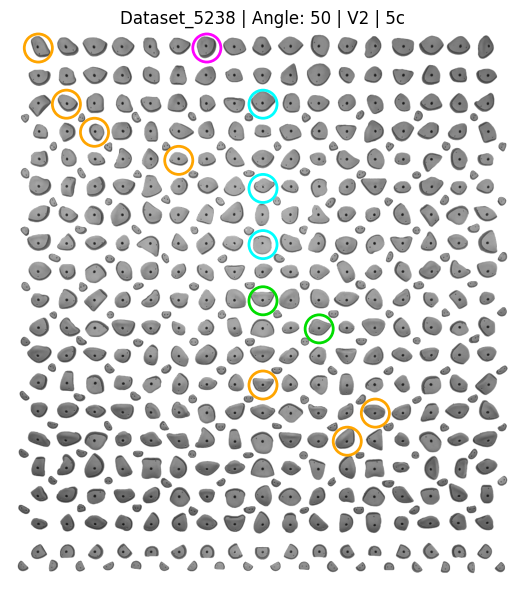

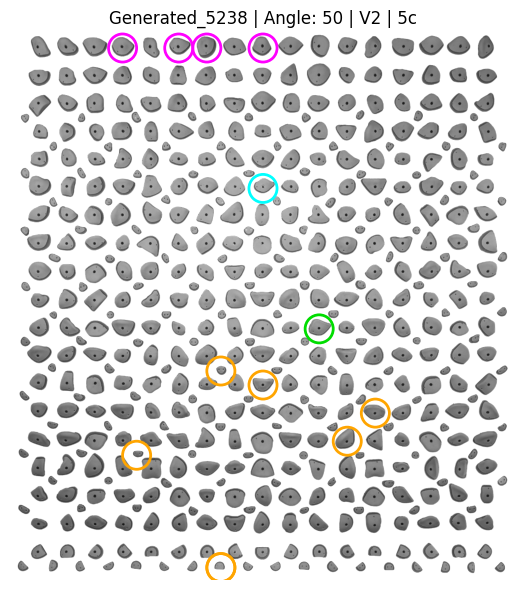

Prompt:    angle50 grade26 feet1113 feet1130 start1232 hand1281
Dataset:   angle50 grade26 feet1113 feet1130 start1232 hand1281 hand1298 hand1345 hand1367 finish1387 feet1528 feet1531
Generated: angle50 grade26 feet1113 feet1130 start1232 hand1281 finish1387


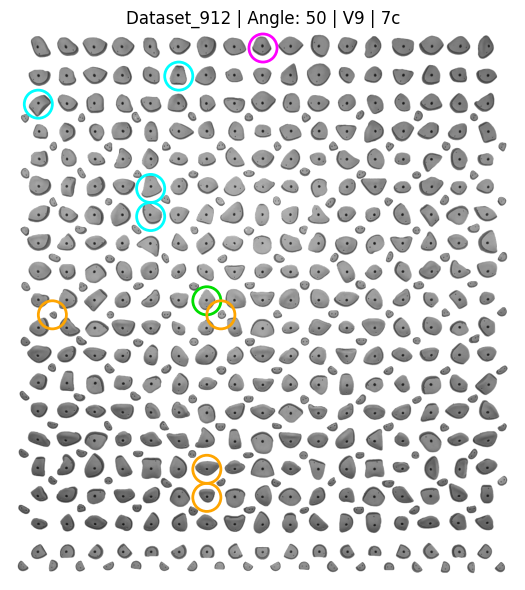

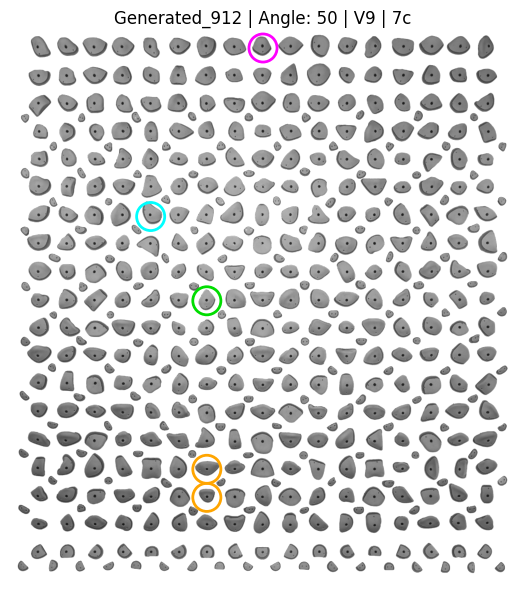

In [43]:
model.generate_and_compare_with_dataset(datasets['test'], num_samples=2, prompt_length=7, save_fig=False)

In [44]:
trainer.model.test_generate_from_prompts(skip_special_tokens=True)
model.test_generate_from_prompts(skip_special_tokens=True)
#both works

GENERATION TEST
Prompt         : 
Generated      : finish1387 finish1391 feet1531 feet1503 feet1504 feet1506 finish1392

Prompt         : angle40
Generated      : angle40 finish1383 feet1456 finish1387 finish1390 hand1340 feet1534

Prompt         : angle40 grade15
Generated      : angle40 grade15 feet1457 feet1456 finish1391 hand1340 finish1382 finish1390 feet1453

Prompt         : angle40 grade15 start1139
Generated      : angle40 grade15 start1139 finish1385

Prompt         : angle40 grade15 hand1315 hand1131
Generated      : angle40 grade15 hand1315 hand1131 finish1383 finish1379 finish1389

Prompt         : angle50 grade20 feet1117 start1131 start1163 hand1234 hand1247 hand1302
Generated      : angle50 grade20 feet1117 start1131 start1163 hand1234 hand1247 hand1302 finish1387 feet1451 finish1384 feet1455 feet1531 finish1383 feet1506

GENERATION TEST
Prompt         : 
Generated      : hand1300 finish1387 finish1382 finish1382 finish1390 finish1391 feet1459 feet1485 finish1390 finish

Prompt    : angle40 grade20
Generated : angle40 grade20 finish1387 finish1391 feet1459 feet1506 feet1531 feet1456 feet1506 feet1534 feet1540 feet1544 feet1513 feet1505 feet1551 feet1542 feet1560
angle40 grade20 finish1387 finish1391 feet1459 feet1506 feet1531 feet1456 feet1506 feet1534 feet1540 feet1544 feet1513 feet1505 feet1551 feet1542 feet1560


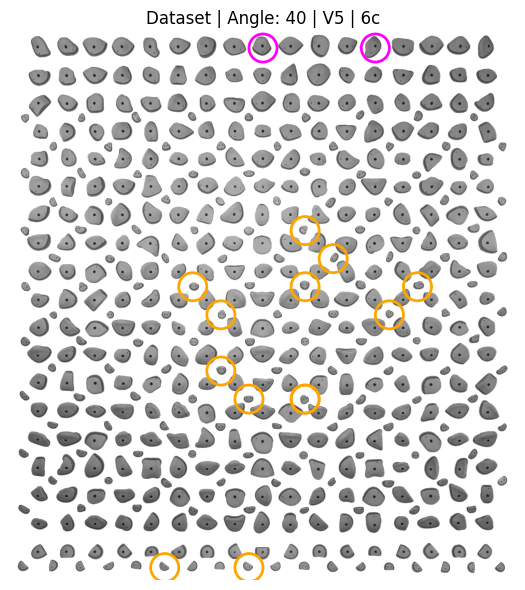

In [51]:
### draft ver. (1epoch trained)
route = model.generate_with_constraint(
    tokenizer=model.tokenizer,
    prompt="angle40 grade20",
    min_holds=5,
    max_holds=15,
    use_constraints=True,
    temperature = 0.2,
    top_p = 0.8,
)
print(route)
from src.visualization import Visualization
viz = Visualization()
viz.plot_boulder("_".join(route.split()), name = "Dataset");


In [54]:
import torch
import torch.nn.functional as F

def visualize_future_mask_behavior(model, tokenizer, dataset, sample_idx=0, top_k=3):
    """
    Visualize the model's predictions for each token in a sample,
    skipping ignored positions (labels == -100), showing top-k predictions.
    """
    device = next(model.parameters()).device

    example = dataset[sample_idx]
    input_ids = torch.tensor(example["input_ids"], device=device).unsqueeze(0)
    labels = torch.tensor(example["labels"], device=device).unsqueeze(0)

    # --- forward ---
    with torch.no_grad():
        outputs = model(input_ids=input_ids, labels=labels)
        logits = outputs['logits']

    probs = F.softmax(logits, dim=-1)

    tokens = [tokenizer.decode([t]) for t in input_ids[0]]
    # Replace -100 with a valid token id (e.g., 0) just for decoding
    targets = [tokenizer.decode([t if t >= 0 else 0]) for t in labels[0]]

    print("\n=== Visualization of causal mask behavior ===")

    for i in range(len(tokens)):
        if labels[0, i] == -100:
            continue  # skip ignored positions

        context_str = tokenizer.decode(input_ids[0, :i], skip_special_tokens=True)
        next_token = targets[i]
        top_preds = torch.topk(probs[0, i - 1], k=top_k)
        pred_tokens = [tokenizer.decode([tid]) for tid in top_preds.indices]

        in_topk = next_token in pred_tokens

        print(f"\nContext (0→{i}): {repr(context_str)}")
        print(f"Target token: {repr(next_token)}")
        for j, (tok, prob) in enumerate(zip(pred_tokens, top_preds.values)):
            print(f"   {j+1:2d}. {repr(tok):15s}  p={prob.item():.4f}")


visualize_future_mask_behavior(model, tokenizer, datasets['train'], sample_idx=0, top_k=3)


=== Visualization of causal mask behavior ===

Context (0→1): ''
Target token: 'angle45'
    1. 'finish1387'     p=0.0981
    2. 'finish1383'     p=0.0262
    3. 'finish1391'     p=0.0235

Context (0→2): 'angle45'
Target token: 'grade23'
    1. 'finish1387'     p=0.1010
    2. 'finish1383'     p=0.0262
    3. 'finish1391'     p=0.0238

Context (0→3): 'angle45 grade23'
Target token: 'feet1080'
    1. 'finish1387'     p=0.1013
    2. 'finish1383'     p=0.0265
    3. 'finish1391'     p=0.0236

Context (0→4): 'angle45 grade23 feet1080'
Target token: 'feet1082'
    1. 'finish1387'     p=0.1007
    2. 'finish1383'     p=0.0263
    3. 'finish1391'     p=0.0238

Context (0→5): 'angle45 grade23 feet1080 feet1082'
Target token: 'start1149'
    1. 'finish1387'     p=0.0961
    2. 'finish1383'     p=0.0257
    3. 'finish1391'     p=0.0239

Context (0→6): 'angle45 grade23 feet1080 feet1082 start1149'
Target token: 'hand1234'
    1. 'finish1387'     p=0.1029
    2. 'finish1383'     p=0.0253
    3. 

# import back+test

In [6]:
import os
import sys
from pathlib import Path
# project_root = Path(__file__).resolve().parent.parent if '__file__' in globals() else Path.cwd().parent

# os.chdir(project_root)
# sys.path.insert(0, str(project_root))
os.getcwd()

'/content/KilterTransformer'

In [2]:
%cd KilterTransformer

[Errno 2] No such file or directory: 'KilterTransformer'
/content


In [7]:
from datetime import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    GPT2LMHeadModel,
    GPT2Config,
    PreTrainedTokenizerFast,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    LogitsProcessor,
    LogitsProcessorList,
)
from typing import List, Tuple, Optional
import re
from src.tokenizer import train_tokenizer, tokenize_datasets
from src.data_processing import DataPreprocessing
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# from src.gpt import KilterGPT, RouteConstraintProcessor
"""
Climbing route generation model - training and inference.
"""
from datetime import datetime
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    GPT2LMHeadModel,
    GPT2Config,
    PreTrainedTokenizerFast,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    LogitsProcessor,
    LogitsProcessorList,
)
from typing import List, Tuple, Optional
import re
from src.tokenizer import train_tokenizer, tokenize_datasets
from src.data_processing import DataPreprocessing
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from PIL import Image


In [9]:
OUT_DIR = "/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/20251106_200546_gpt_defaultloss_debug"

dp = DataPreprocessing()
datasets = dp.load_climbs()

train_test = datasets.train_test_split(test_size=0.2, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

datasets = {'train': train_test['train'], 'val': val_test['train'], 'test': val_test['test']}

tokenizer = train_tokenizer(datasets, OUT_DIR)
datasets = tokenize_datasets(datasets, tokenizer)

Loaded 76992 routes from cache data/climbs_cleaned.csv
Built vocab with 1932 tokens (1928 custom)

Vocab size: 1932 tokens
First 10 tokens: [('feet1598', 502), ('hand1233', 1140), ('feet1303', 258), ('feet1530', 434), ('start1203', 634), ('finish1087', 1470), ('finish1144', 1527), ('start1315', 746), ('feet1144', 99), ('hand1245', 1152)]

Sample encodings:

Input:  angle35_grade14_feet1595_start1400
Tokens: ['[BOS]', 'angle35', 'grade14', 'feet1595', '[UNK]', '[EOS]', '[PAD]x19']

Input:  angle40_grade15_feet1595_start1596_hand1597_finish1598
Tokens: ['[BOS]', 'angle40', 'grade15', 'feet1595', 'start1596', 'hand1597', 'finish1598', '[EOS]', '[PAD]x17']

Saving tokenizer to /content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/20251106_200546_gpt_defaultloss_debug


Map:   0%|          | 0/61593 [00:00<?, ? examples/s]

Map:   0%|          | 0/7699 [00:00<?, ? examples/s]

Map:   0%|          | 0/7700 [00:00<?, ? examples/s]

In [15]:
class KilterGPT(nn.Module):
    """GPT-2 model for generating Kilter Board climbing routes."""

    def __init__(
        self,
        n_embd: int = 256,
        n_head: int = 4,
        n_layer: int = 6,
        n_positions: int = 128,
        dropout: float = 0.1,
        tokenizer: Optional[PreTrainedTokenizerFast] = None,
        ):

        super().__init__()

        self.tokenizer = tokenizer
        config = GPT2Config(
            n_embd=n_embd,
            n_head=n_head,
            n_layer=n_layer,
            n_positions=n_positions,
            n_ctx=n_positions,
            resid_pdrop=dropout,
            embd_pdrop=dropout,
            attn_pdrop=dropout,
            vocab_size=tokenizer.vocab_size,
            )
        self.config = config
        self.model = GPT2LMHeadModel(config)


    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        """
        Forward pass with order-invariant loss.

        If labels provided: Computes custom multi-target loss
        If labels None: Returns logits only (for generation)
        """
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)

        if labels is not None:
            # Order-invariant loss: any remaining hold is valid
            logits = outputs.logits
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()

            # Use vectorized loss function (imported from your loss module)
            loss = self._any_of_next_token_loss_vectorized(shift_logits, shift_labels)
            outputs.loss = loss

        return outputs

    @staticmethod
    def _any_of_next_token_loss_vectorized(logits, shift_labels, ignore_index=-100,
                                       bos_token_id=1, eos_token_id=2, print_debug=False):
        """
        Order-invariant loss for climbing routes.

        Loss behavior:
        - BOS (token_id=1): Never predicted (always first in sequence)
        - Angle, Grade, Holds: Set-loss (order-invariant, any remaining token is valid)
        - EOS (token_id=2): Excluded from valid set (standard single-target prediction)
        - Padding: Ignored

        Args:
            logits: (B, L, V) # batch_size, seq_len, vocab_size
            shift_labels: (B, L)
            ignore_index: Padding marker (default -100)
            bos_token_id: BOS token ID (default 1)
            eos_token_id: EOS token ID (default 2)
        """
        B, L, V = logits.shape
        device = logits.device

        # Compute log probabilities
        log_probs = F.log_softmax(logits, dim=-1)  # (B, L, V)

        # mask for valid label positions
        # [TRUE, TRUE, TRUE, TRUE, FALSE, FALSE, ...] where FALSE are PADs
        valid_positions = (shift_labels != ignore_index)  # (B, L)


        # upper-triangle of 1 size (L, L)
        future_mask = torch.triu(torch.ones((L, L), device=device, dtype=torch.bool))

        # Combine: for each sequence, each position sees all future tokens that are valid
        # Expand: valid_positions.unsqueeze(1): (B, L) → (B, 1, L)
        # valid_future_mask[b, i, j] = True if label[j] is valid future of i and j >= i
        valid_future_mask = valid_positions.unsqueeze(1) & future_mask  # (B, L, L)
        # valid_future_mask[0][0] => [TRUE, TRUE, TRUE, ..., TRUE, FALSE, ..., FALSE] (True for all valid tokens + False for PADs)
        # valid_future_mask[0][1] => [FALSE, TRUE, TRUE, ..., TRUE, FALSE, ..., FALSE]
        # valid_future_mask[0][2] => [FALSE, FALSE, TRUE, ..., TRUE, FALSE, ..., FALSE]
        # valid_future_mask[0][-seq_len] => [FALSE, FALSE, FALSE, ..., FALSE, FALSE, ..., FALSE]


        labels_expanded = shift_labels.unsqueeze(1).expand(-1, L, -1)  # (B, L, L)
        # labels_expanded[0] => (B, L) 2d array, row count = batch_size B=16
        # each row labels_expanded[0][0] is [token0, token1, token2, ..., token_seq_len, -100, -100, ...] (len L=21)

        # Set ignored ones to -1
        labels_expanded = torch.where(valid_future_mask, labels_expanded, -torch.ones_like(labels_expanded))
        # each row labels_expanded[0][0] is now [token0, token1, token2, ..., token_seq_len, -1, -1, ...] (len L=21)
        # labels_expanded[0][0] => [token0, token1, token2, ..., token_seq_len, -1, -1, ...] (len L=21)
        # labels_expanded[0][1] => [-1,     token1, token2, ..., token_seq_len, -1, -1, ...]
        # labels_expanded[0][2] => [-1,       -1,   token2, ..., token_seq_len, -1, -1, ...]


        # ========================================================================
        # NEW: Exclude EOS from the valid set (EOS should be predicted exactly, not as part of set)
        # ========================================================================
        # Create mask for EOS tokens in future positions
        # Shape: (B, L, L) - True where future token is EOS
        is_eos_future = (labels_expanded == eos_token_id)

        # Remove EOS from valid_future_mask
        # This makes EOS tokens NOT contribute to the set-loss
        # They will only be predicted when they are the ONLY remaining token
        valid_future_mask = valid_future_mask & ~is_eos_future
        # Explanation:
        # Before: valid_future_mask[0][i] might include EOS among valid predictions
        # After:  valid_future_mask[0][i] excludes EOS from the set
        # Result: When predicting, model won't see EOS as "any valid token"
        #         EOS only gets predicted when it's the last token (standard behavior)


        # Build boolean mask per vocab id using scatter_
        valid_token_mask = torch.zeros((B, L, V), dtype=torch.bool, device=device)
        scatter_idx = labels_expanded.clone()
        scatter_idx[scatter_idx < 0] = 0  # convert -1 to dummy 0, to ignore the positions

        valid_token_mask.scatter_(dim=2, index=scatter_idx, src=valid_future_mask)  # mark valid vocab positions
        # (B, L, V)(16, 21, 1932)
        # valid_token_mask[0][0]
        # [PAD, BOS, EOS, UNK, ---angle---, ---grade---, ---holds---]
        # valid_token_mask[0][0], sum=12 < seq_len
        # [FALSE, TRUE, FALSE, ---one True angle, ---one True grade, ---several True holds---]
        #              ^^^^^ NOTE: EOS is now FALSE (excluded from set)

        # valid_token_mask[0][1], sum=11
        # [FALSE, FALSE, FALSE, ---one True angle, ---one True grade, ---several True holds---]
        #         ^^^^^ BOS excluded    ^^^^^ EOS excluded

        # valid_token_mask[0][2], sum=10
        # [FALSE, FALSE, FALSE, ---all False angle, ---one True grade, ---several True holds---]

        # valid_token_mask[0][3], sum=9
        # [FALSE, FALSE, FALSE, ---all False angle, ---all False grade, ---several True holds---]

        # and then the hold tokens ...

        # note, for next example in batch:
        # valid_token_mask[1][0], sum=17 < seq_len
        # [FALSE, TRUE, FALSE, ---one True angle, ---one True grade, ---several True holds---]

        valid_token_mask[:, :, 0] &= (labels_expanded[:, :, 0] != 0)  # fix dummy zeros if any


        # ========================================================================
        # NEW: Add back EOS prediction when it's the only valid next token
        # ========================================================================
        # Find positions where the next token should be EOS
        # Shape: (B, L)
        next_is_eos = (shift_labels == eos_token_id)

        # At these positions, enable EOS in the vocabulary mask
        # This allows standard cross-entropy loss for EOS prediction
        valid_token_mask[:, :, eos_token_id] |= next_is_eos
        # Explanation:
        # If position i should predict EOS (next_is_eos[b,i] = True):
        #   - Set valid_token_mask[b, i, eos_token_id] = True
        #   - This makes ONLY EOS valid at this position
        #   - Standard single-target prediction for EOS!
        '''
        valid_token_mask[:, :, bos_token_id] = False
        '''

        # Filter(/mask) log_probs for only valid positions
        masked_log_probs = torch.where(valid_token_mask, log_probs, torch.full_like(log_probs, -1e9))
        # log_probs[0][0] =>        [-7.6137, -6.4946, -7.7223, ...] the usual
        # valid_token_mask[0][0] => [FALSE,    TRUE,    FALSE,   ...] (BOS and EOS excluded)
        # masked_log_probs[0][0] => [-1e9,    -6.4946,  -1e9,   ...]


        # Combine log(P(token1) + P(token2) + ... + P(tokenN))
        log_sum = torch.logsumexp(masked_log_probs, dim=-1)  # (B, L)
        # For positions with multiple valid tokens: log(P1 + P2 + ... + PN) = set-loss
        # For positions with only EOS valid: log(P_eos) = standard single-target loss


        # log(P1) + log(P2) + ... + log(PN)
        # count_valid = valid_token_mask.sum(dim=-1).clamp(min=1)
        # log_sum = masked_log_probs.sum(dim=-1) / count_valid


        # Only keep positions that had at least one valid target
        has_valid = valid_token_mask.any(dim=-1) # Shape: (B, L)

        # average negative log-likelihood
        loss = -log_sum[has_valid].mean()
        # loss = -log_sum[has_valid].sum() / valid_positions.sum()


        if print_debug:
            print("\n" + "="*70)
            print("DEBUG: Loss Computation Details")
            print("="*70)
            print(f"\nSequence 0 breakdown:")
            for i in range(min(8, L)):
                if has_valid[0, i]:
                    valid_tokens = [j for j in range(V) if valid_token_mask[0, i, j]]
                    num_valid = len(valid_tokens)
                    is_eos_pos = next_is_eos[0, i].item()
                    print(f"  Pos {i}: {num_valid} valid tokens | Target={shift_labels[0,i].item():4d} | "
                        f"EOS-only={is_eos_pos} | log_sum={log_sum[0,i].item():7.3f}")


        return loss

    @classmethod
    def load_from_checkpoint(cls, OUT_DIR, datasets):
        """
        Recreate KilterGPT, tokenizer, and Trainer from a saved OUT_DIR.
        Returns: (gpt, trainer, tokenizer)
        """
        import torch
        import os
        from transformers import (
            PreTrainedTokenizerFast,
            GPT2Config,
            GPT2LMHeadModel,
            DataCollatorForLanguageModeling,
            Trainer,
        )

        # === Paths ===
        CHECKPOINTS = sorted(
            [d for d in os.listdir(OUT_DIR) if d.startswith("checkpoint-")],
            key=lambda x: int(x.split("-")[1])
        )
        CHECKPOINT_DIR = os.path.join(OUT_DIR, CHECKPOINTS[-1]) if CHECKPOINTS else OUT_DIR
        MODEL_BIN = f"{CHECKPOINT_DIR}/pytorch_model.bin"
        ARGS_BIN = f"{CHECKPOINT_DIR}/training_args.bin"
        print(OUT_DIR)
        print(MODEL_BIN)
        # === 1. Load tokenizer ===
        tokenizer = PreTrainedTokenizerFast.from_pretrained(OUT_DIR)
        print(f"Tokenizer vocab size: {tokenizer.vocab_size}")

        # === 2. Load config (must use same vocab_size) ===
        config = GPT2Config.from_pretrained(OUT_DIR)
        config.vocab_size = tokenizer.vocab_size  # force match (avoid resizing warning)
        print(config)
        # # === 3. Create model and load weights ===
        gpt = cls(tokenizer=tokenizer)
        state_dict = torch.load(MODEL_BIN, map_location="cpu")
        state_dict = {k.replace("model.", ""): v for k, v in state_dict.items()}
        gpt.model.load_state_dict(state_dict, strict=False)
        gpt.model.resize_token_embeddings(len(tokenizer))

        # gpt.model = GPT2LMHeadModel.from_pretrained(OUT_DIR, config=config)
        # gpt.model.resize_token_embeddings(len(tokenizer))


        print("✅ Model embedding shape:", gpt.model.transformer.wte.weight.shape)

        # === 4. Load TrainingArguments ===
        training_args = torch.load(ARGS_BIN, weights_only=False)

        # === 5. Create Trainer ===
        data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
        trainer = Trainer(
            model=gpt,
            args=training_args,
            data_collator=data_collator,
            train_dataset=datasets["train"],
            eval_dataset=datasets["val"],
        )

        return gpt, trainer, tokenizer


    def generate_route(
        self,
        prompt: str = "angle50 grade20",
        max_new_tokens: int = 20,
        temperature: float = 0.8,
        top_k: int = 50,
        top_p: float = 0.9,
        skip_special_tokens=True,
        device: Optional[str] = None,
        ) -> str:
        """
        Generate a single climbing route from a prompt.

        Returns decoded tokens as a string
        """
        if self.tokenizer is None:
            raise ValueError("Tokenizer not set. Pass tokenizer during __init__ or use set_tokenizer()")

        if device is None:
            device = next(self.parameters()).device

        self.eval()
        self.to(device)

        # Encode prompt
        input_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(device) #

        # Generate
        with torch.no_grad():
            output_ids = self.model.generate(
                input_ids=input_ids[:, :-1], #self.tokenizer.encode auto-add EOS to prompt, we remove it
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_k=top_k,
                top_p=top_p,
                do_sample=True,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
                repetition_penalty=1.2,
            )

        return self.tokenizer.decode(output_ids[0], skip_special_tokens=skip_special_tokens)

    def test_generate_from_prompts(
        self,
        test_prompts: Optional[List[str]] = None,
        device: Optional[str] = None,
        **generate_kwargs
        ):
        if test_prompts is None:
            test_prompts = [
                "",
                "angle40",
                "angle40 grade15",
                "angle40 grade15 start1139",
                "angle40 grade15 hand1315 hand1131",
                "angle50 grade20 feet1117 start1131 start1163 hand1234 hand1247 hand1302"
            ]

        if device is None:
            device = next(self.parameters()).device

        print("=" * 70)
        print("GENERATION TEST")
        print("=" * 70)

        for prompt in test_prompts:
            generated = self.generate_route(prompt, device=device, **generate_kwargs)
            # print(f"\n{'Prompt':<15}: {prompt}")
            print(f"{'Prompt':<15}: {prompt}")
            print(f"{'Generated':<15}: {generated}\n")

    def generate_and_compare_with_dataset(
        self,
        dataset,
        num_samples: int = 2,
        prompt_length: int = 7,
        save_fig = False,
        **generate_kwargs
        ):
        """
        Compare model generation with real dataset examples.

        Args:
            dataset: Dataset to sample from (should have 'input_ids' field)
            num_samples: Number of examples to compare
            prompt_length: Number of tokens to use as prompt
            viz: Optional visualizer object with plot_boulder() method
            **generate_kwargs: Arguments for generate_route()
        """
        from src.visualization import Visualization
        viz = Visualization()

        if self.tokenizer is None:
            raise ValueError("Tokenizer not set")

        device = next(self.parameters()).device

        print("=" * 70)
        print("DATASET COMPARISON")
        print("=" * 70)

        # Sample random indices
        indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

        for idx in indices:
            # Get dataset example
            example_ids = dataset[idx]['input_ids']

            # Create prompt from first k tokens
            prompt_ids = example_ids[:prompt_length]
            prompt_ids = [tid for tid in prompt_ids if tid != self.tokenizer.pad_token_id]

            # Decode
            prompt = self.tokenizer.decode(prompt_ids, skip_special_tokens=True)
            full_route = self.tokenizer.decode(example_ids, skip_special_tokens=True)

            # Generate from prompt
            generated = self.generate_route(prompt, device=device, **generate_kwargs)

            print(f"Prompt:    {prompt}")
            print(f"Dataset:   {full_route}")
            print(f"Generated: {generated}")

            viz.plot_boulder("_".join(full_route.split()), name=f"Dataset_{idx}", save_fig=save_fig)
            viz.plot_boulder("_".join(generated.split()), name=f"Generated_{idx}", save_fig=save_fig)

            if save_fig:
                os.makedirs("figs", exist_ok=True)
                fig.savefig(f"figs/compare_{idx}.png", dpi=150)

    def generate_with_constraint(
        self,
        tokenizer,
        prompt: str,
        max_new_tokens: int = 64,
        temperature: float = 1.0,
        top_p: float = 0.95,
        min_holds: int = 5,
        max_holds: int = 12,
        use_constraints: bool = True,
        ) -> str:
        """
        Generate a route with optional constraint enforcement.
        """
        device = "cuda" if torch.cuda.is_available() else "cpu"
        model_inputs = tokenizer(prompt, return_tensors="pt").to(device)

        logits_processor = None
        if use_constraints:
            logits_processor = LogitsProcessorList([
                RouteConstraintProcessor(tokenizer, min_holds=min_holds, max_holds=max_holds)
            ])

        with torch.no_grad():
            output_ids = self.model.generate(
                **model_inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_k=50,
                top_p=top_p,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
                logits_processor=logits_processor,
                repetition_penalty=1.2,
            )

        decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        print(f"{'Prompt':<10}: {prompt}")
        print(f"{'Generated':<10}: {decoded}")

        return decoded


# OUT_DIR = "models/climb_gpt_shuffle/20251106_161420_gpt_defaultloss_debug"
OUT_DIR = "/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/20251107_115444_gpt_defaultloss_5epoch"
OUT_DIR = "/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/20251106_200546_gpt_defaultloss_debug"


In [16]:
gpt, trainer, tokenizer = KilterGPT.load_from_checkpoint(
    OUT_DIR=OUT_DIR,
    datasets=datasets,
)
# gpt is a KilterGPT class, use gpt.method()

/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/20251106_200546_gpt_defaultloss_debug
/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/20251106_200546_gpt_defaultloss_debug/checkpoint-76000/pytorch_model.bin
Tokenizer vocab size: 1932
GPT2Config {
  "activation_function": "gelu_new",
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "transformers_version": "4.57.1",
  "use_cache": true,
  "vocab_size": 1932
}



RuntimeError: Error(s) in loading state_dict for GPT2LMHeadModel:
	size mismatch for transformer.wte.weight: copying a param with shape torch.Size([50257, 256]) from checkpoint, the shape in current model is torch.Size([1932, 256]).
	size mismatch for lm_head.weight: copying a param with shape torch.Size([50257, 256]) from checkpoint, the shape in current model is torch.Size([1932, 256]).

In [11]:
# trainer.evaluate(datasets["test"], metric_key_prefix="test")

{'test_loss': 5.936681747436523,
 'test_model_preparation_time': 0.0034,
 'test_runtime': 19.8637,
 'test_samples_per_second': 387.643,
 'test_steps_per_second': 48.48}

In [ ]:
gpt.test_generate_from_prompts(skip_special_tokens=True)
# trainer.model.test_generate_from_prompts(skip_special_tokens=True)
# both works

Prompt    : angle40 grade20 finish1387
Generated : angle40 grade20 finish1387 finish1387 hand1353 hand1353 hand1353 hand1215 feet1533 hand1254 feet1566 feet1511 feet1469 feet1452


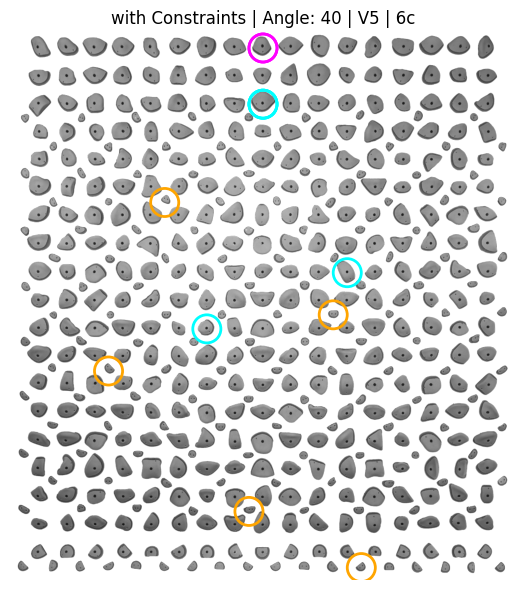

In [21]:
route = gpt.generate_with_constraint(
    tokenizer=gpt.tokenizer,
    prompt="angle40 grade20 finish1387",
    min_holds=5,
    max_holds=12,
    temperature = 0.2,
    top_p = 0.8,
)

from src.visualization import Visualization
viz = Visualization()
viz.plot_boulder("_".join(route.split()), name = "with Constraints");


DATASET COMPARISON
Prompt:    angle50 grade15 feet1152 feet1170 feet1183 start1219
Dataset:   angle50 grade15 feet1152 feet1170 feet1183 start1219 start1234 hand1268 hand1302 feet1316 feet1330 feet1346 hand1353 feet1379 finish1385
Generated: angle50 grade15 feet1152 feet1170 feet1183 start1219 finish1506 feet1095 hand1215


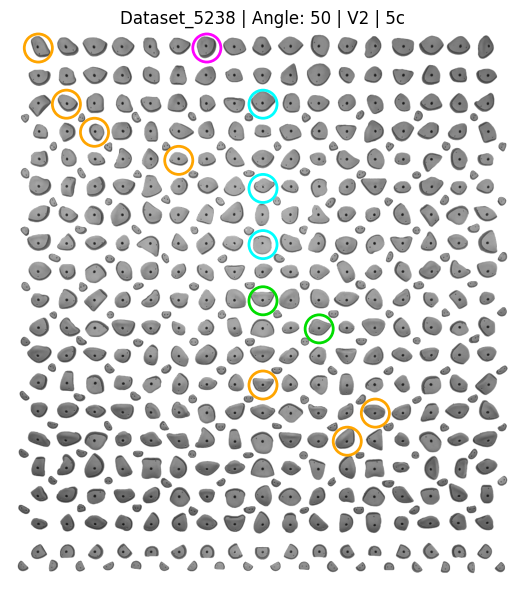

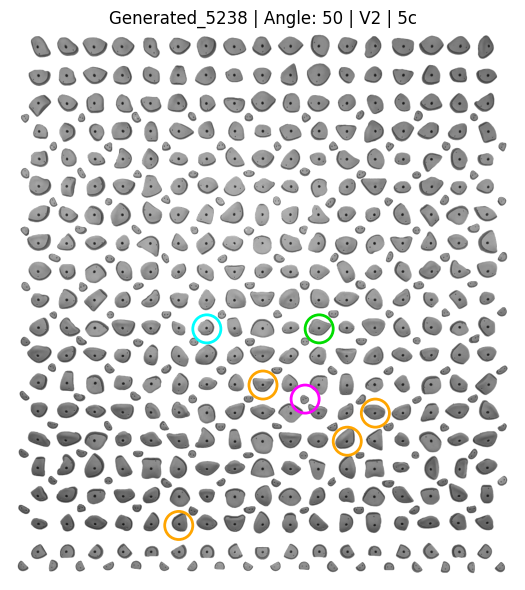

Prompt:    angle50 grade26 feet1113 feet1130 start1232 hand1281
Dataset:   angle50 grade26 feet1113 feet1130 start1232 hand1281 hand1298 hand1345 hand1367 finish1387 feet1528 feet1531
Generated: angle50 grade26 feet1113 feet1130 start1232 hand1281 hand1598 feet1489 feet1480 finish1395 hand1353 hand1252 finish1387 finish1387 feet1533 feet1533 hand1302 hand1354 start1311 hand1215


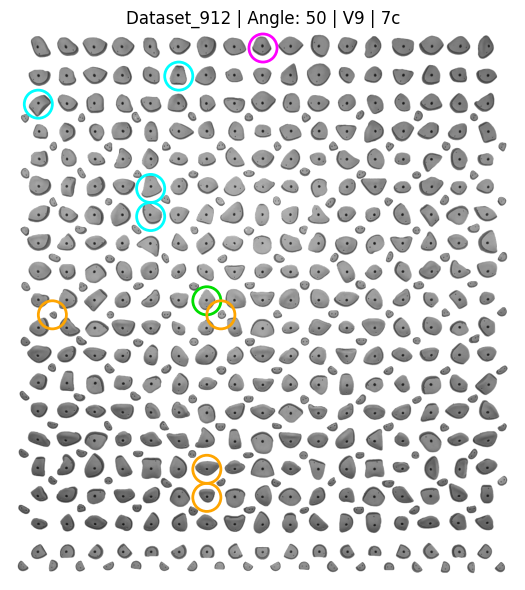

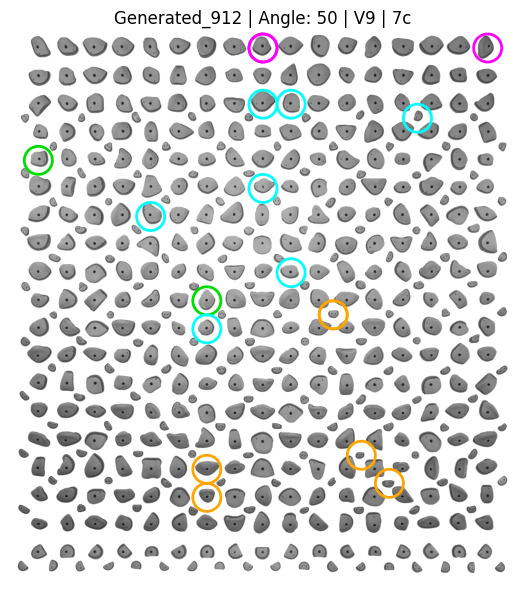

In [7]:
gpt.generate_and_compare_with_dataset(datasets['test'], num_samples=2, prompt_length=7, save_fig=False)

Prompt    : angle40 grade20 hand1139
Generated : angle40 grade20 hand1139 start1518 finish1126 feet1183 feet1255 feet1541 start1231 feet1541 hand1341 hand1573 finish1212 hand1549


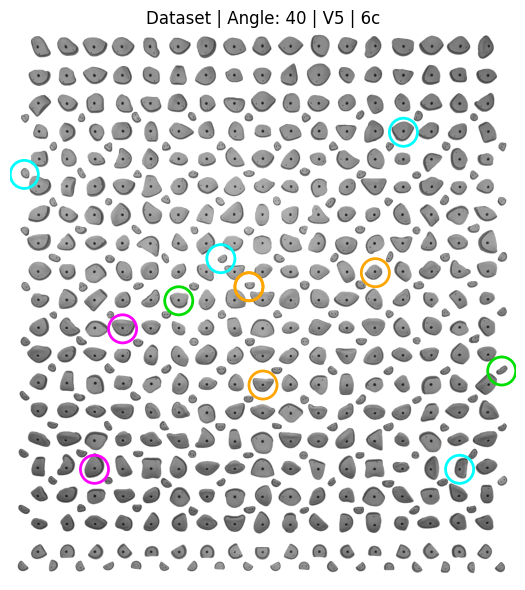

In [15]:
### draft ver. (1epoch trained)
route = gpt.generate_with_constraint(
    tokenizer=gpt.tokenizer,
    prompt="angle40 grade20 hand1139",
    min_holds=5,
    max_holds=12,
    use_constraints=True,
    temperature = 1.0,
    top_p = 0.8,
)

from src.visualization import Visualization
viz = Visualization()
viz.plot_boulder("_".join(route.split()), name = "Dataset");


In [ ]:
##old ver.
gpt.generate_and_compare_with_dataset(datasets['test'], num_samples=2, prompt_length=7, save_fig=False)

In [ ]:
# FINE BUT SLOW AF

# pred = trainer.predict(datasets["test"], metric_key_prefix="test")

# logits = torch.tensor(pred.predictions)  # (B, L, V)
# labels = torch.tensor(pred.label_ids)    # (B, L)
# B, L, V = logits.shape

# # ------------------------------------------------------
# # Compute standard LM loss (same as GPT2)
# # shift so that tokens < t predict token t
# shift_logits = logits[..., :-1, :].contiguous()
# shift_labels = labels[..., 1:].contiguous()

# # ignore padding
# loss_fct = torch.nn.CrossEntropyLoss(ignore_index=-100)
# loss = loss_fct(shift_logits.view(-1, V), shift_labels.view(-1))
# print(f"Manual test loss: {loss.item():.4f}")


In [ ]:
def visualize_future_mask_behavior(model, tokenizer, dataset, sample_idx=0, top_k=3):

    device = next(model.parameters()).device

    example = dataset[sample_idx]
    input_ids = torch.tensor(example["input_ids"], device=device).unsqueeze(0)
    labels = input_ids.clone()


    # --- forward ---
    with torch.no_grad():
        outputs = model(input_ids=input_ids, labels=labels) ### not generation
        logits = outputs['logits']

    probs = F.softmax(logits, dim=-1)

    tokens = [tokenizer.decode([t]) for t in input_ids[0]]
    targets = [tokenizer.decode([t]) for t in labels[0]]

    print("\n=== Visualization of causal mask behavior ===")

    for i in range(len(tokens)):
        context_str = tokenizer.decode(input_ids[0, :i], skip_special_tokens=True)
        next_token = targets[i]
        top_preds = torch.topk(probs[0, i - 1], k=top_k)
        pred_tokens = [tokenizer.decode([tid]) for tid in top_preds.indices]

        print(f"\nContext (0→{i}): {repr(context_str)}")
        print(f"Target token: {repr(next_token)}")
        for j, (tok, prob) in enumerate(zip(pred_tokens, top_preds.values)):
            print(f"   {j+1:2d}. {repr(tok):15s}  p={prob.item():.4f}")


visualize_future_mask_behavior(
    model=trainer.model,
    tokenizer=tokenizer,
    dataset=datasets['test'],
    sample_idx=3
)


# on-the-fly augment

In [ ]:
class AugmentedRouteDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, tokenizer, num_augments=1):
        self.ds = hf_dataset
        self.tokenizer = tokenizer
        self.num_augments = num_augments
        self.n = len(hf_dataset)

    def __len__(self):
        return self.n * (self.num_augments + 1)  # originals + N augments

    def __getitem__(self, idx):
        base_idx = idx % self.n      # which real example in the base dataset
        aug_idx  = idx // self.n     # which augmentation slot (0 = original)

        example = self.ds[base_idx]
        tokens = example["input_ids"]

        if aug_idx > 0:  # 0 = original, others = augmented
            eos_idx = tokens.index(self.tokenizer.eos_token_id) if self.tokenizer.eos_token_id in tokens else len(tokens)
            prefix = tokens[:3]
            holds = tokens[3:eos_idx]
            tail = tokens[eos_idx:]

            random.shuffle(holds)          # in-place
            tokens = prefix + holds + tail  # use the shuffled list


        max_len = tokenizer.model_max_length  # or a fixed number

        example["input_ids"] = tokens + [tokenizer.pad_token_id] * (max_len - len(tokens))
        example["labels"] = tokens + [-100] * (max_len - len(tokens)) #ignore_index for padding
        example["token_type_ids"] = [0] * max_len
        example["attention_mask"] = [1] * len(tokens) + [0] * (max_len - len(tokens))


        return example



In [ ]:
project = "climb-gpt-shuffle"
run_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_gpt_defaultloss_aug_5epoch"
OUT_DIR = f"/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/{run_name}"

wandb.init(
    project=project,
    name=run_name,
    config={
        "architecture": "GPT-SetLoss",
        "n_embd": 256,
        "n_head": 4,
        "n_layer": 6,
        "n_positions": 128,
        "dropout": 0.1,
        "epochs": 20,
        "batch_size": 16,
        "learning_rate": 1e-4,
        "weight_decay": 0.01,
        "gradient_accumulation_steps": 1,
        "early_stopping_patience": 5,
        "allow_empty_prompt": True,
        "min_prefix_len": 1,
    }
)

model = KilterGPT(
    n_embd=256,
    n_head=4,
    n_layer=6,
    n_positions=128,
    dropout=0.1
    )
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="steps",
    save_strategy="best",
    save_total_limit=2,
    overwrite_output_dir=True,
    logging_steps=100,  # Log more frequently for wandb
    eval_steps=2000,    ########
    save_steps=2000,    ########
    num_train_epochs=5,  ########
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    weight_decay=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    report_to="wandb",  # "wandb"
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{OUT_DIR}/logs",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    save_safetensors=False,
    run_name='run_name',
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=datasets["train"],
    eval_dataset=datasets["val"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

augmented_dataset = AugmentedRouteDataset(datasets["train"], tokenizer, num_augments=1)
trainer.train_dataset = augmented_dataset

In [ ]:
trainer.train()

In [ ]:
from src.gpt import KilterGPT
gpt, tokenizer, trainer = KilterGPT.load_last_checkpoint(OUT_DIR)


In [ ]:
trainer.evaluate(datasets["test"], metric_key_prefix="test")

In [ ]:
gpt.test_generate_from_prompts(skip_special_tokens=True)

In [ ]:
route = gpt.generate_with_constraint(
    tokenizer=gpt.tokenizer,
    prompt="angle40 grade20 hand1139",
    min_holds=5,
    max_holds=12,
    use_constraints=True,
    temperature = 1.0,
    top_p = 0.8,
)

from src.visualization import Visualization
viz = Visualization()
viz.plot_boulder("_".join(route.split()), name = "Dataset");


In [ ]:
# for augmentation(shuffle holds)
# train slower, equal eval_loss proportionately
# test_loss almost the same (3.52)
# generation looks better tho but still generate [EOS] right after prompt


# order-invariant loss
Instead of predicting the *exact next token* (as in normal language modeling),
we want the model to predict **any valid next hold** — since order among holds doesn't matter.

This means at position *i*, the valid next tokens are **all remaining holds** in the sequence.

Shape explanation:
- logits: `(B, L, V)`  → batch_size × seq_len × vocab_size
- labels: `(B, L)`     → each position contains the target token index or -100 for padding

We’ll compute the log-probability of the **set of valid tokens** instead of a single token.



## loss func

In [ ]:
import torch
import torch.nn.functional as F

# def any_of_next_token_loss(logits, shift_labels, ignore_index=-100, print_debug=False):
#     """
#     logits:   Tensor shape (B, L, V)  -- already shifted logits for predicting next token
#               (e.g. logits[..., :-1, :] from model outputs)
#     shift_labels: Tensor shape (B, L) -- labels shifted left (labels[...,1:])
#                   entries are vocab indices or ignore_index
#     Returns:
#       loss: scalar tensor (mean over valid positions)
#     """
#     B, L, V = logits.shape
#     device = logits.device

#     # Convert logits -> log_probs
#     log_probs = F.log_softmax(logits, dim=-1)  # (B, L, V)

#     # Build valid-mask per position that marks every token that occurs later in the sequence.
#     # For each batch b and position i we want all labels in shift_labels[b, i:] (excluding ignore_index).
#     # We'll build valid_mask by iterating over positions (L is small, so it's fine).
#     valid_mask = torch.zeros((B, L, V), dtype=torch.bool, device=device)

#     for pos in range(L):
#         # tail_labels: shape (B, tail_len)
#         tail_labels = shift_labels[:, pos:]  # (B, L-pos)

#         # flatten to indices with mask of non-ignore
#         flat = tail_labels.reshape(-1)  # (B*(L-pos),)
#         keep = flat != ignore_index
#         if keep.any():
#             kept_indices = flat[keep].long()  # the vocabulary indices we want to mark
#             # To place them back into (B, pos) positions we need which batch each came from:
#             # compute batch index for each row in tail_labels
#             # create tensor of batch ids repeated for each position in tail
#             batch_ids = torch.arange(B, device=device).unsqueeze(1).expand(B, L-pos).reshape(-1)[keep]
#             # set valid_mask[batch_ids, pos, kept_indices] = True
#             valid_mask[batch_ids, pos, kept_indices] = True

#     # Now for each position we may have zero valid tokens (should be ignored)
#     has_valid = valid_mask.any(dim=-1)  # (B, L) bool

#     # For positions with no valid tokens, set masked logits to -inf so logsumexp -> -inf.
#     neg_inf = -1e9
#     masked_log_probs = torch.where(valid_mask, log_probs, neg_inf)  # (B, L, V)

#     # Compute logsumexp over vocab dim -> log probability mass on valid tokens
#     log_sum = torch.logsumexp(masked_log_probs, dim=-1)  # (B, L)

#     # Positions without valid tokens will have log_sum approx = neg_inf. We mask them out.
#     valid_log_sum = log_sum[has_valid]  # 1D tensor of only valid positions

#     if valid_log_sum.numel() == 0:
#         # no valid positions: return zero or raise depending on preference
#         return torch.tensor(0.0, device=device, requires_grad=True)

#     loss = - valid_log_sum.mean()


#     # if print_debug:
#     #     print("=== DEBUG (loop version) ===")
#     #     print("logits.shape:", logits.shape)
#     #     print("shift_labels:\n", shift_labels)
#     #     print("valid_mask.sum per pos:", valid_mask.sum(-1))
#     #     print("has_valid:", has_valid)
#     #     print("log_sum:", log_sum)
#     #     print("loss:", loss.item())
#     return loss

"""
VECTORIZED LOSS: Using Upper-Triangular Masks

Key insight: For each position i, valid targets are ALL tokens at positions j≥i

Example sequence: [BOS, angle, hold1, hold2, hold3, EOS]
Position:           0     1      2      3      4     5

Future mask (upper triangular, each row shows what position i can see):
     j:  0  1  2  3  4  5
   i=0 [[1, 1, 1, 1, 1, 1],  ← pos 0 sees all future
   i=1  [0, 1, 1, 1, 1, 1],  ← pos 1 sees 1-5
   i=2  [0, 0, 1, 1, 1, 1],  ← pos 2 sees 2-5
   i=3  [0, 0, 0, 1, 1, 1],  ← pos 3 sees 3-5
   i=4  [0, 0, 0, 0, 1, 1],  ← pos 4 sees 4-5
   i=5  [0, 0, 0, 0, 0, 1]]  ← pos 5 sees 5 only
"""
def any_of_next_token_loss_vectorized(logits, shift_labels, ignore_index=-100,
                                       bos_token_id=1, eos_token_id=2, print_debug=False):
    """
    Order-invariant loss for climbing routes.

    Loss behavior:
    - BOS (token_id=1): Never predicted (always first in sequence)
    - Angle, Grade, Holds: Set-loss (order-invariant, any remaining token is valid)
    - EOS (token_id=2): Excluded from valid set (standard single-target prediction)
    - Padding: Ignored

    Args:
        logits: (B, L, V) # batch_size, seq_len, vocab_size
        shift_labels: (B, L)
        ignore_index: Padding marker (default -100)
        bos_token_id: BOS token ID (default 1)
        eos_token_id: EOS token ID (default 2)
    """
    B, L, V = logits.shape
    device = logits.device

    # Compute log probabilities
    log_probs = F.log_softmax(logits, dim=-1)  # (B, L, V)

    # mask for valid label positions
    # [TRUE, TRUE, TRUE, TRUE, FALSE, FALSE, ...] where FALSE are PADs
    valid_positions = (shift_labels != ignore_index)  # (B, L)


    # upper-triangle of 1 size (L, L)
    future_mask = torch.triu(torch.ones((L, L), device=device, dtype=torch.bool))

    # Combine: for each sequence, each position sees all future tokens that are valid
    # Expand: valid_positions.unsqueeze(1): (B, L) → (B, 1, L)
    # valid_future_mask[b, i, j] = True if label[j] is valid future of i and j >= i
    valid_future_mask = valid_positions.unsqueeze(1) & future_mask  # (B, L, L)
    # valid_future_mask[0][0] => [TRUE, TRUE, TRUE, ..., TRUE, FALSE, ..., FALSE] (True for all valid tokens + False for PADs)
    # valid_future_mask[0][1] => [FALSE, TRUE, TRUE, ..., TRUE, FALSE, ..., FALSE]
    # valid_future_mask[0][2] => [FALSE, FALSE, TRUE, ..., TRUE, FALSE, ..., FALSE]
    # valid_future_mask[0][-seq_len] => [FALSE, FALSE, FALSE, ..., FALSE, FALSE, ..., FALSE]


    labels_expanded = shift_labels.unsqueeze(1).expand(-1, L, -1)  # (B, L, L)
    # labels_expanded[0] => (B, L) 2d array, row count = batch_size B=16
    # each row labels_expanded[0][0] is [token0, token1, token2, ..., token_seq_len, -100, -100, ...] (len L=21)

    # Set ignored ones to -1
    labels_expanded = torch.where(valid_future_mask, labels_expanded, -torch.ones_like(labels_expanded))
    # each row labels_expanded[0][0] is now [token0, token1, token2, ..., token_seq_len, -1, -1, ...] (len L=21)
    # labels_expanded[0][0] => [token0, token1, token2, ..., token_seq_len, -1, -1, ...] (len L=21)
    # labels_expanded[0][1] => [-1,     token1, token2, ..., token_seq_len, -1, -1, ...]
    # labels_expanded[0][2] => [-1,       -1,   token2, ..., token_seq_len, -1, -1, ...]


    # ========================================================================
    # NEW: Exclude EOS from the valid set (EOS should be predicted exactly, not as part of set)
    # ========================================================================
    # Create mask for EOS tokens in future positions
    # Shape: (B, L, L) - True where future token is EOS
    is_eos_future = (labels_expanded == eos_token_id)

    # Remove EOS from valid_future_mask
    # This makes EOS tokens NOT contribute to the set-loss
    # They will only be predicted when they are the ONLY remaining token
    valid_future_mask = valid_future_mask & ~is_eos_future
    # Explanation:
    # Before: valid_future_mask[0][i] might include EOS among valid predictions
    # After:  valid_future_mask[0][i] excludes EOS from the set
    # Result: When predicting, model won't see EOS as "any valid token"
    #         EOS only gets predicted when it's the last token (standard behavior)


    # Build boolean mask per vocab id using scatter_
    valid_token_mask = torch.zeros((B, L, V), dtype=torch.bool, device=device)
    scatter_idx = labels_expanded.clone()
    scatter_idx[scatter_idx < 0] = 0  # convert -1 to dummy 0, to ignore the positions

    valid_token_mask.scatter_(dim=2, index=scatter_idx, src=valid_future_mask)  # mark valid vocab positions
    # (B, L, V)(16, 21, 1932)
    # valid_token_mask[0][0]
    # [PAD, BOS, EOS, UNK, ---angle---, ---grade---, ---holds---]
    # valid_token_mask[0][0], sum=12 < seq_len
    # [FALSE, TRUE, FALSE, ---one True angle, ---one True grade, ---several True holds---]
    #              ^^^^^ NOTE: EOS is now FALSE (excluded from set)

    # valid_token_mask[0][1], sum=11
    # [FALSE, FALSE, FALSE, ---one True angle, ---one True grade, ---several True holds---]
    #         ^^^^^ BOS excluded    ^^^^^ EOS excluded

    # valid_token_mask[0][2], sum=10
    # [FALSE, FALSE, FALSE, ---all False angle, ---one True grade, ---several True holds---]

    # valid_token_mask[0][3], sum=9
    # [FALSE, FALSE, FALSE, ---all False angle, ---all False grade, ---several True holds---]

    # and then the hold tokens ...

    # note, for next example in batch:
    # valid_token_mask[1][0], sum=17 < seq_len
    # [FALSE, TRUE, FALSE, ---one True angle, ---one True grade, ---several True holds---]

    valid_token_mask[:, :, 0] &= (labels_expanded[:, :, 0] != 0)  # fix dummy zeros if any


    # ========================================================================
    # NEW: Add back EOS prediction when it's the only valid next token
    # ========================================================================
    # Find positions where the next token should be EOS
    # Shape: (B, L)
    next_is_eos = (shift_labels == eos_token_id)

    # At these positions, enable EOS in the vocabulary mask
    # This allows standard cross-entropy loss for EOS prediction
    valid_token_mask[:, :, eos_token_id] |= next_is_eos
    # Explanation:
    # If position i should predict EOS (next_is_eos[b,i] = True):
    #   - Set valid_token_mask[b, i, eos_token_id] = True
    #   - This makes ONLY EOS valid at this position
    #   - Standard single-target prediction for EOS!
    '''
    valid_token_mask[:, :, bos_token_id] = False
    '''

    # Filter(/mask) log_probs for only valid positions
    masked_log_probs = torch.where(valid_token_mask, log_probs, torch.full_like(log_probs, -1e9))
    # log_probs[0][0] =>        [-7.6137, -6.4946, -7.7223, ...] the usual
    # valid_token_mask[0][0] => [FALSE,    TRUE,    FALSE,   ...] (BOS and EOS excluded)
    # masked_log_probs[0][0] => [-1e9,    -6.4946,  -1e9,   ...]


    # Combine log(P(token1) + P(token2) + ... + P(tokenN))
    log_sum = torch.logsumexp(masked_log_probs, dim=-1)  # (B, L)
    # For positions with multiple valid tokens: log(P1 + P2 + ... + PN) = set-loss
    # For positions with only EOS valid: log(P_eos) = standard single-target loss


    # log(P1) + log(P2) + ... + log(PN)
    # count_valid = valid_token_mask.sum(dim=-1).clamp(min=1)
    # log_sum = masked_log_probs.sum(dim=-1) / count_valid


    # Only keep positions that had at least one valid target
    has_valid = valid_token_mask.any(dim=-1) # Shape: (B, L)

    # average negative log-likelihood
    loss = -log_sum[has_valid].mean()
    # loss = -log_sum[has_valid].sum() / valid_positions.sum()


    if print_debug:
        print("\n" + "="*70)
        print("DEBUG: Loss Computation Details")
        print("="*70)
        print(f"\nSequence 0 breakdown:")
        for i in range(min(8, L)):
            if has_valid[0, i]:
                valid_tokens = [j for j in range(V) if valid_token_mask[0, i, j]]
                num_valid = len(valid_tokens)
                is_eos_pos = next_is_eos[0, i].item()
                print(f"  Pos {i}: {num_valid} valid tokens | Target={shift_labels[0,i].item():4d} | "
                      f"EOS-only={is_eos_pos} | log_sum={log_sum[0,i].item():7.3f}")


    return loss




## train

In [ ]:
class KilterGPT(nn.Module):
    """GPT-2 model for generating Kilter Board climbing routes."""
    def __init__(
        self,
        vocab_size: int,
        n_embd: int = 192,
        n_head: int = 3,
        n_layer: int = 3,
        n_positions: int = 128,
        dropout: float = 0.1
        ):
        super().__init__()
        config = GPT2Config(
            vocab_size=vocab_size,
            n_embd=n_embd,
            n_head=n_head,
            n_layer=n_layer,
            n_positions=n_positions,
            n_ctx=n_positions,
            resid_pdrop=dropout,
            embd_pdrop=dropout,
            attn_pdrop=dropout,
        )
        self.model = GPT2LMHeadModel(config)
        self.config = config

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=None)

        logits = outputs.logits  # (B, L, V) (batch_size, seq_len, vocab_size)

        # shift predictions and labels for next-token prediction
        shift_logits = logits[..., :-1, :].contiguous()   # predict token at t+1 using tokens up to t
        shift_labels = labels[..., 1:].contiguous()       # label for position t is token at t+1

        loss = any_of_next_token_loss_vectorized(shift_logits, shift_labels, ignore_index=-100)
        outputs.loss = loss

        return {'loss': loss, 'logits':logits}

    def generate(self, *args, **kwargs):
        return self.model.generate(*args, **kwargs)

In [ ]:
wandb.init(
    project="climb-gpt-shuffle",
    name=f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_gpt_newloss_debug",
    config={
        "architecture": "GPT-SetLoss",
        "n_embd": 256,
        "n_head": 4,
        "n_layer": 6,
        "n_positions": 128,
        "dropout": 0.1,
        "epochs": 30,
        "batch_size": 16,
        "learning_rate": 1e-4,
        "weight_decay": 0.01,
        "gradient_accumulation_steps": 1,
        "early_stopping_patience": 5,
        "allow_empty_prompt": True,
        "min_prefix_len": 1,  # Changed from 3 to allow BOS-only
    }
)

run_name = wandb.run.name

OUT_DIR = f"/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/{run_name}"
# OUT_DIR = f"models/climb_gpt_shuffle/{run_name}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


model = KilterGPT(
    vocab_size=tokenizer.vocab_size,
    n_embd=256,
    n_head=4,
    n_layer=6,
    n_positions=128,
    dropout=0.1
    )
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="steps",
    save_strategy="steps",
    save_total_limit=3,
    overwrite_output_dir=True,
    logging_steps=100,  # Log more frequently for wandb
    eval_steps=3000,
    save_steps=3000,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    weight_decay=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    report_to="wandb",  # Enable wandb reporting
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{OUT_DIR}/logs",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    save_safetensors=False,
    run_name=run_name,
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=datasets["train"],  ### back to train_set without augment
    eval_dataset=datasets["val"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

In [ ]:
trainer.train()

In [ ]:
test_loss_gen(trainer, model)

# new loss+aug

In [ ]:
wandb.init(
    project="climb-gpt-shuffle",
    name=f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_gpt_newloss_aug",
    config={
        "architecture": "GPT-SetLoss",
        "n_embd": 256,
        "n_head": 4,
        "n_layer": 6,
        "n_positions": 128,
        "dropout": 0.1,
        "epochs": 30,
        "batch_size": 16,
        "learning_rate": 1e-4,
        "weight_decay": 0.01,
        "gradient_accumulation_steps": 1,
        "early_stopping_patience": 5,
        "allow_empty_prompt": True,
        "min_prefix_len": 1,  # Changed from 3 to allow BOS-only
    }
)

run_name = wandb.run.name

OUT_DIR = f"/content/drive/MyDrive/KilterTransformer/models/climb_gpt_shuffle/{run_name}"
# OUT_DIR = f"models/climb_gpt_shuffle/{run_name}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


model = KilterGPT(
    vocab_size=tokenizer.vocab_size,
    n_embd=256,
    n_head=4,
    n_layer=6,
    n_positions=128,
    dropout=0.1
    )
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="steps",
    save_strategy="steps",
    save_total_limit=3,
    overwrite_output_dir=True,
    logging_steps=100,  # Log more frequently for wandb
    eval_steps=3000,
    save_steps=3000,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    weight_decay=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    report_to="wandb",  # Enable wandb reporting
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{OUT_DIR}/logs",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    save_safetensors=False,
    run_name=run_name,
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=datasets["train"],  ### back to train_set without augment
    eval_dataset=datasets["val"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

In [ ]:
augmented_dataset = AugmentedRouteDataset(datasets["train"], tokenizer, num_augments=1)
trainer.train_dataset = augmented_dataset

In [ ]:
trainer.train()

In [ ]:
test_loss_gen(trainer, model)

# draft---debug loss

In [ ]:
device = next(model.parameters()).device
# INSPECTIGN THE FIRST BATCH (with size B=16)
batch = next(iter(trainer.get_train_dataloader()))
# print({k: v.shape for k, v in batch.items()})

batch = {k: v.to(device) for k, v in batch.items()}

model.eval()
with torch.no_grad():
    outputs = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        labels=batch["labels"],
    )

logits = outputs.logits.detach().cpu()
labels = batch["labels"].cpu()

# loss_loop = any_of_next_token_loss(logits, labels, print_debug=True)
loss_vec  = any_of_next_token_loss_vectorized(logits, labels, print_debug=True)
loss_vec

In [ ]:
vocab_size = 6
seq_len = 3
batch_size = 1

logits = torch.tensor([
    [
        [1.0, 2.0, 3.0, 0.0, -1.0, 0.5],   # position 0
        [2.0, 1.0, 0.5, -0.5, 3.0, 0.0],   # position 1
        [0.0, 1.0, 0.0, 2.0, -1.0, 3.0]    # position 2
    ]
], dtype=torch.float)

# labels for the same sequence (token ids)
# Shape: (1, 3)
labels = torch.tensor([[1, 3, 5]])

# 🔥 Run the loss with debug prints
loss = any_of_next_token_loss_vectorized(logits, labels, print_debug=False)
loss

In [ ]:

# Get the train dataloader from your Trainer
train_dataloader = trainer.get_train_dataloader()

# Grab one batch
batch = next(iter(train_dataloader))

# Inspect what’s inside
for k, v in batch.items():
    print(k, v.shape)

# Move model to device and set to eval
model = trainer.model
device = next(model.parameters()).device
model.eval()

# Move batch tensors to device
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

# Forward pass (disable gradient)
with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels,
    )

# Extract logits
logits = outputs.logits  # shape (B, L, V)
print(f"logits shape: {logits.shape}")

# Also inspect a slice
print("Example logits[0, 0, :10]:", logits[0, 0, :10])
print("Example labels[0, :10]:", labels[0, :10])

# Optionally, compute your custom loss
shift_logits = logits[..., :-1, :].contiguous()
shift_labels = labels[..., 1:].contiguous()

loss = any_of_next_token_loss_vectorized(shift_logits, shift_labels, print_debug=False)
print("Custom loss:", loss.item())


In [ ]:
import torch.nn.functional as F

idx = 3
input_decoded = tokenizer.decode(input_ids[idx], skip_special_tokens=True)
print(f"\n🧩 Input sequence:\n{input_decoded}\n")

# Compute probabilities for this example
probs = F.softmax(logits[idx], dim=-1)
topk = torch.topk(probs, 3, dim=-1)  # top-3 predictions at each position

print("🔍 Token-level predictions (first 10 tokens):\n")
for i in range(10):  # first 10 tokens
    target_id = labels[idx, i].item()
    target_str = tokenizer.decode([target_id])

    preds_ids = topk.indices[i]
    preds_probs = topk.values[i]
    preds = [(tokenizer.decode([pid.item()]), float(pprob)) for pid, pprob in zip(preds_ids, preds_probs)]

    preds_display = ", ".join([f"{tok} ({p:.5f})" for tok, p in preds])
    print(f"Target: {target_str:10} | Top-3: {preds_display}")


# draft---augment

- in dataset, usually, start holds come first
- e.g. sequence that is actually climbed: [BOS, angle40, grade15, start111, start999, hand222, foot444, hand333, finish777, EOS, (PAD)]
- but the model should be able to generate like this:
- given sequence [BOS, angle40, grade15, hand222, foot444]
    -  predict any of [start111, start999, and333, finish777, EOS] since they all complete the climbing route
    - order in the token is invariant(irrelavant) to the climbs after decoding
- therefore, training set should have shuffled sequence of holds as new augmented examples
- we'll skip [BOS, grade, angle, EOS] and shuffle the holds, append to the train set, maybe 2-3x

# draft---training

In [ ]:
eval_dataloader = trainer.get_eval_dataloader()

eval_loss_manual = []
device = next(model.parameters()).device

for batch in eval_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**batch)
        eval_loss_manual.append(outputs["loss"].item())

manual_eval_loss = sum(eval_loss_manual) / len(eval_loss_manual)
print(f"Manual eval loss: {manual_eval_loss:.9f}")


In [ ]:
with torch.no_grad():
    out = model(**batch)
    custom_loss = any_of_next_token_loss_vectorized(out["logits"], batch["labels"])
print("Model loss:", out["loss"].item(), "Manual loss:", custom_loss.item())


In [ ]:
import torch

# Get the train dataloader from your Trainer
train_dataloader = trainer.get_train_dataloader()

# Grab one batch
batch = next(iter(train_dataloader))

# Inspect what’s inside
for k, v in batch.items():
    print(k, v.shape)

# Move model to device and set to eval
model = trainer.model
device = next(model.parameters()).device
model.eval()

# Move batch tensors to device
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

# Forward pass (disable gradient)
with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels,
    )

# Extract logits
logits = outputs['logits']  # shape (B, L, V)
print(f"logits shape: {logits.shape}")

# Also inspect a slice
print("Example logits[0, 0, :10]:", logits[0, 0, :10])
print("Example labels[0, :10]:", labels[0, :10])

# Optionally, compute your custom loss
shift_logits = logits[..., :-1, :].contiguous()
shift_labels = labels[..., 1:].contiguous()

loss = any_of_next_token_loss_vectorized(shift_logits, shift_labels, print_debug=False)
print("Custom loss:", loss.item())


In [ ]:
import torch.nn.functional as F

idx = 3
input_decoded = tokenizer.decode(input_ids[idx], skip_special_tokens=True)
print(f"\n🧩 Input sequence:\n{input_decoded}\n")

# Compute probabilities for this example
probs = F.softmax(logits[idx], dim=-1)
topk = torch.topk(probs, 3, dim=-1)  # top-3 predictions at each position

print("🔍 Token-level predictions (first 10 tokens):\n")
for i in range(10):  # first 10 tokens
    target_id = labels[idx, i].item()
    target_str = tokenizer.decode([target_id])

    preds_ids = topk.indices[i]
    preds_probs = topk.values[i]
    preds = [(tokenizer.decode([pid.item()]), float(pprob)) for pid, pprob in zip(preds_ids, preds_probs)]

    preds_display = ", ".join([f"{tok} ({p:.5f})" for tok, p in preds])
    print(f"Target: {target_str:10} | Top-3: {preds_display}")


In [ ]:
import torch
import torch.nn.functional as F

def visualize_future_mask_behavior(model, tokenizer, dataset, sample_idx=0, top_k=3):
    device = next(model.parameters()).device

    # --- fetch one sample safely ---
    example = dataset[sample_idx]
    input_ids = torch.tensor(example["input_ids"], device=device).unsqueeze(0)

    # if labels not provided, assume equal to input_ids (typical LM setup)
    if "labels" in example:
        labels = torch.tensor(example["labels"], device=device).unsqueeze(0)
    else:
        labels = input_ids.clone()

    # --- forward ---
    with torch.no_grad():
        outputs = model(input_ids=input_ids, labels=labels)
        logits = outputs['logits']

    # --- softmax for probabilities ---
    probs = F.softmax(logits, dim=-1)

    # --- decode ---
    tokens = [tokenizer.decode([t]) for t in input_ids[0]]
    targets = [tokenizer.decode([t]) for t in labels[0]]

    print("\n=== Visualization of causal mask behavior ===")
    print(f"Sample idx: {sample_idx}\n")

    for i in range(len(tokens)):
        context_str = tokenizer.decode(input_ids[0, :i], skip_special_tokens=True)
        next_token = targets[i]
        top_preds = torch.topk(probs[0, i], k=top_k)
        pred_tokens = [tokenizer.decode([tid]) for tid in top_preds.indices]

        print(f"\n--- Step {i} ---")
        print(f"Context (0→{i}): {repr(context_str)}")
        print(f"Target token: {repr(next_token)}")
        print("Top model predictions:")
        for j, (tok, prob) in enumerate(zip(pred_tokens, top_preds.values)):
            print(f"   {j+1:2d}. {repr(tok):15s}  p={prob.item():.4f}")

    print("\n✅ Done — future masking validated (each step only sees prior context).")


# --- ✅ call on your dataset ---
visualize_future_mask_behavior(
    model=trainer.model,
    tokenizer=tokenizer,
    dataset=trainer.train_dataset,
    sample_idx=3
)


# draft---test

In [ ]:
# assume tokenizer & model are loaded from your fine-tuned checkpoint
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.model
model.to(device)
model.eval()

test_prompts = [
    "[BOS]",
    "[BOS] angle40",
    "[BOS] angle40 grade15",
    "[BOS] angle40 grade15 start1139",
]

# generation config
gen_kwargs = dict(
    max_new_tokens=64,
    do_sample=False,        # deterministic for inspection
    temperature=1.0,
    top_p=0.9,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.convert_tokens_to_ids("[EOS]"),
)

for i, prompt in enumerate(test_prompts):
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(input_ids, **gen_kwargs)

    decoded = tokenizer.decode(output[0], skip_special_tokens=False)
    print(f"\n--- Example {i} ---")
    print(f"Context: {prompt}")
    print(f"Generated: {decoded}")

    # Optional: visualize token-by-token
    tokens = tokenizer.convert_ids_to_tokens(output[0])
    print("Tokens:", tokens)
